In [1]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy
import seaborn as sb
import src.concept_utils as cu


import matplotlib.pyplot as plt
import random as rd
import pickle as pkl

2025-10-27 14:18:42.613006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761571122.716064  111105 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761571122.764279  111105 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Matplotlib is building the font cache; this may take a moment.


In [2]:
sys.path.append(os.getcwd())
sys.path

['/data/4vitry/miniconda3/envs/debiafting/lib/python311.zip',
 '/data/4vitry/miniconda3/envs/debiafting/lib/python3.11',
 '/data/4vitry/miniconda3/envs/debiafting/lib/python3.11/lib-dynload',
 '',
 '/data/4vitry/miniconda3/envs/debiafting/lib/python3.11/site-packages',
 '/data/4vitry/miniconda3/envs/debiafting/lib/python3.11/site-packages/setuptools/_vendor',
 '/tmp/tmpq4yra_xl',
 '/informatik1/students/home/4vitry/Documents/CVDB']

<Axes: >

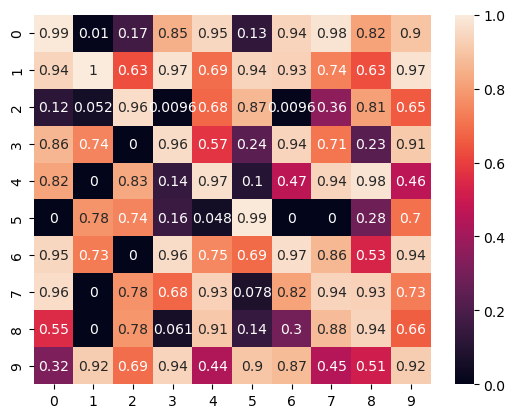

In [3]:
exp_id = 0
exp_name = "MNIST"
with open("/data/4vitry/models/" + exp_name + "/model_" + str(exp_id) + ".pkl", "rb") as f:
    model_res = pkl.load(f)
sb.heatmap(model_res["correctness_matrix"]/model_res["appearance_matrix"], vmin=0, vmax=1, annot=True)


In [4]:
with open(f"/data/4vitry/models/{exp_name}/concepts_{0}_{0}.pkl", "rb") as f:
    concept_res = pkl.load(f)
concept_res["concept_results"][10][0]

{'concept_base': array([[1.32844709e-02, 2.20250734e-03, 4.77680713e-02, 3.05527057e-02,
         7.30695650e-02, 3.02358299e-01, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 3.44886839e-01],
        [1.14267953e-02, 9.67801921e-03, 2.52002385e-02, 2.93953065e-02,
         8.06270391e-02, 1.90325394e-01, 0.00000000e+00, 7.35436901e-02,
         1.11060515e-01, 4.69659984e-01],
        [1.13454266e-02, 1.07773738e-02, 2.82178409e-02, 2.70628389e-02,
         9.00832042e-02, 2.12931931e-01, 0.00000000e+00, 4.48194928e-02,
         8.73669088e-02, 4.84326988e-01],
        [9.65589099e-03, 7.67265819e-03, 4.90978099e-02, 2.92848349e-02,
         7.59887993e-02, 3.32882196e-01, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 3.07358563e-01],
        [8.00860953e-03, 2.05039396e-03, 2.96435170e-02, 3.14681232e-02,
         8.46258402e-02, 3.34769666e-01, 0.00000000e+00, 0.00000000e+00,
         1.76543351e-02, 5.69916904e-01],
        [1.20866904e-02, 1.80494366e-03, 5.4

In [5]:
amount_of_concept = 30
studied_bias = 8
step_amount = 70

For 10 concept, the vector similarity is : [0.         0.00198361 0.00843867 0.02589191 0.04487317 0.07080348
 0.15447868 0.19154794]
For 30 concept, the vector similarity is : [0.00025403 0.00500095 0.02060224 0.04683518 0.06361627 0.19006821
 0.2256114  0.24516478]


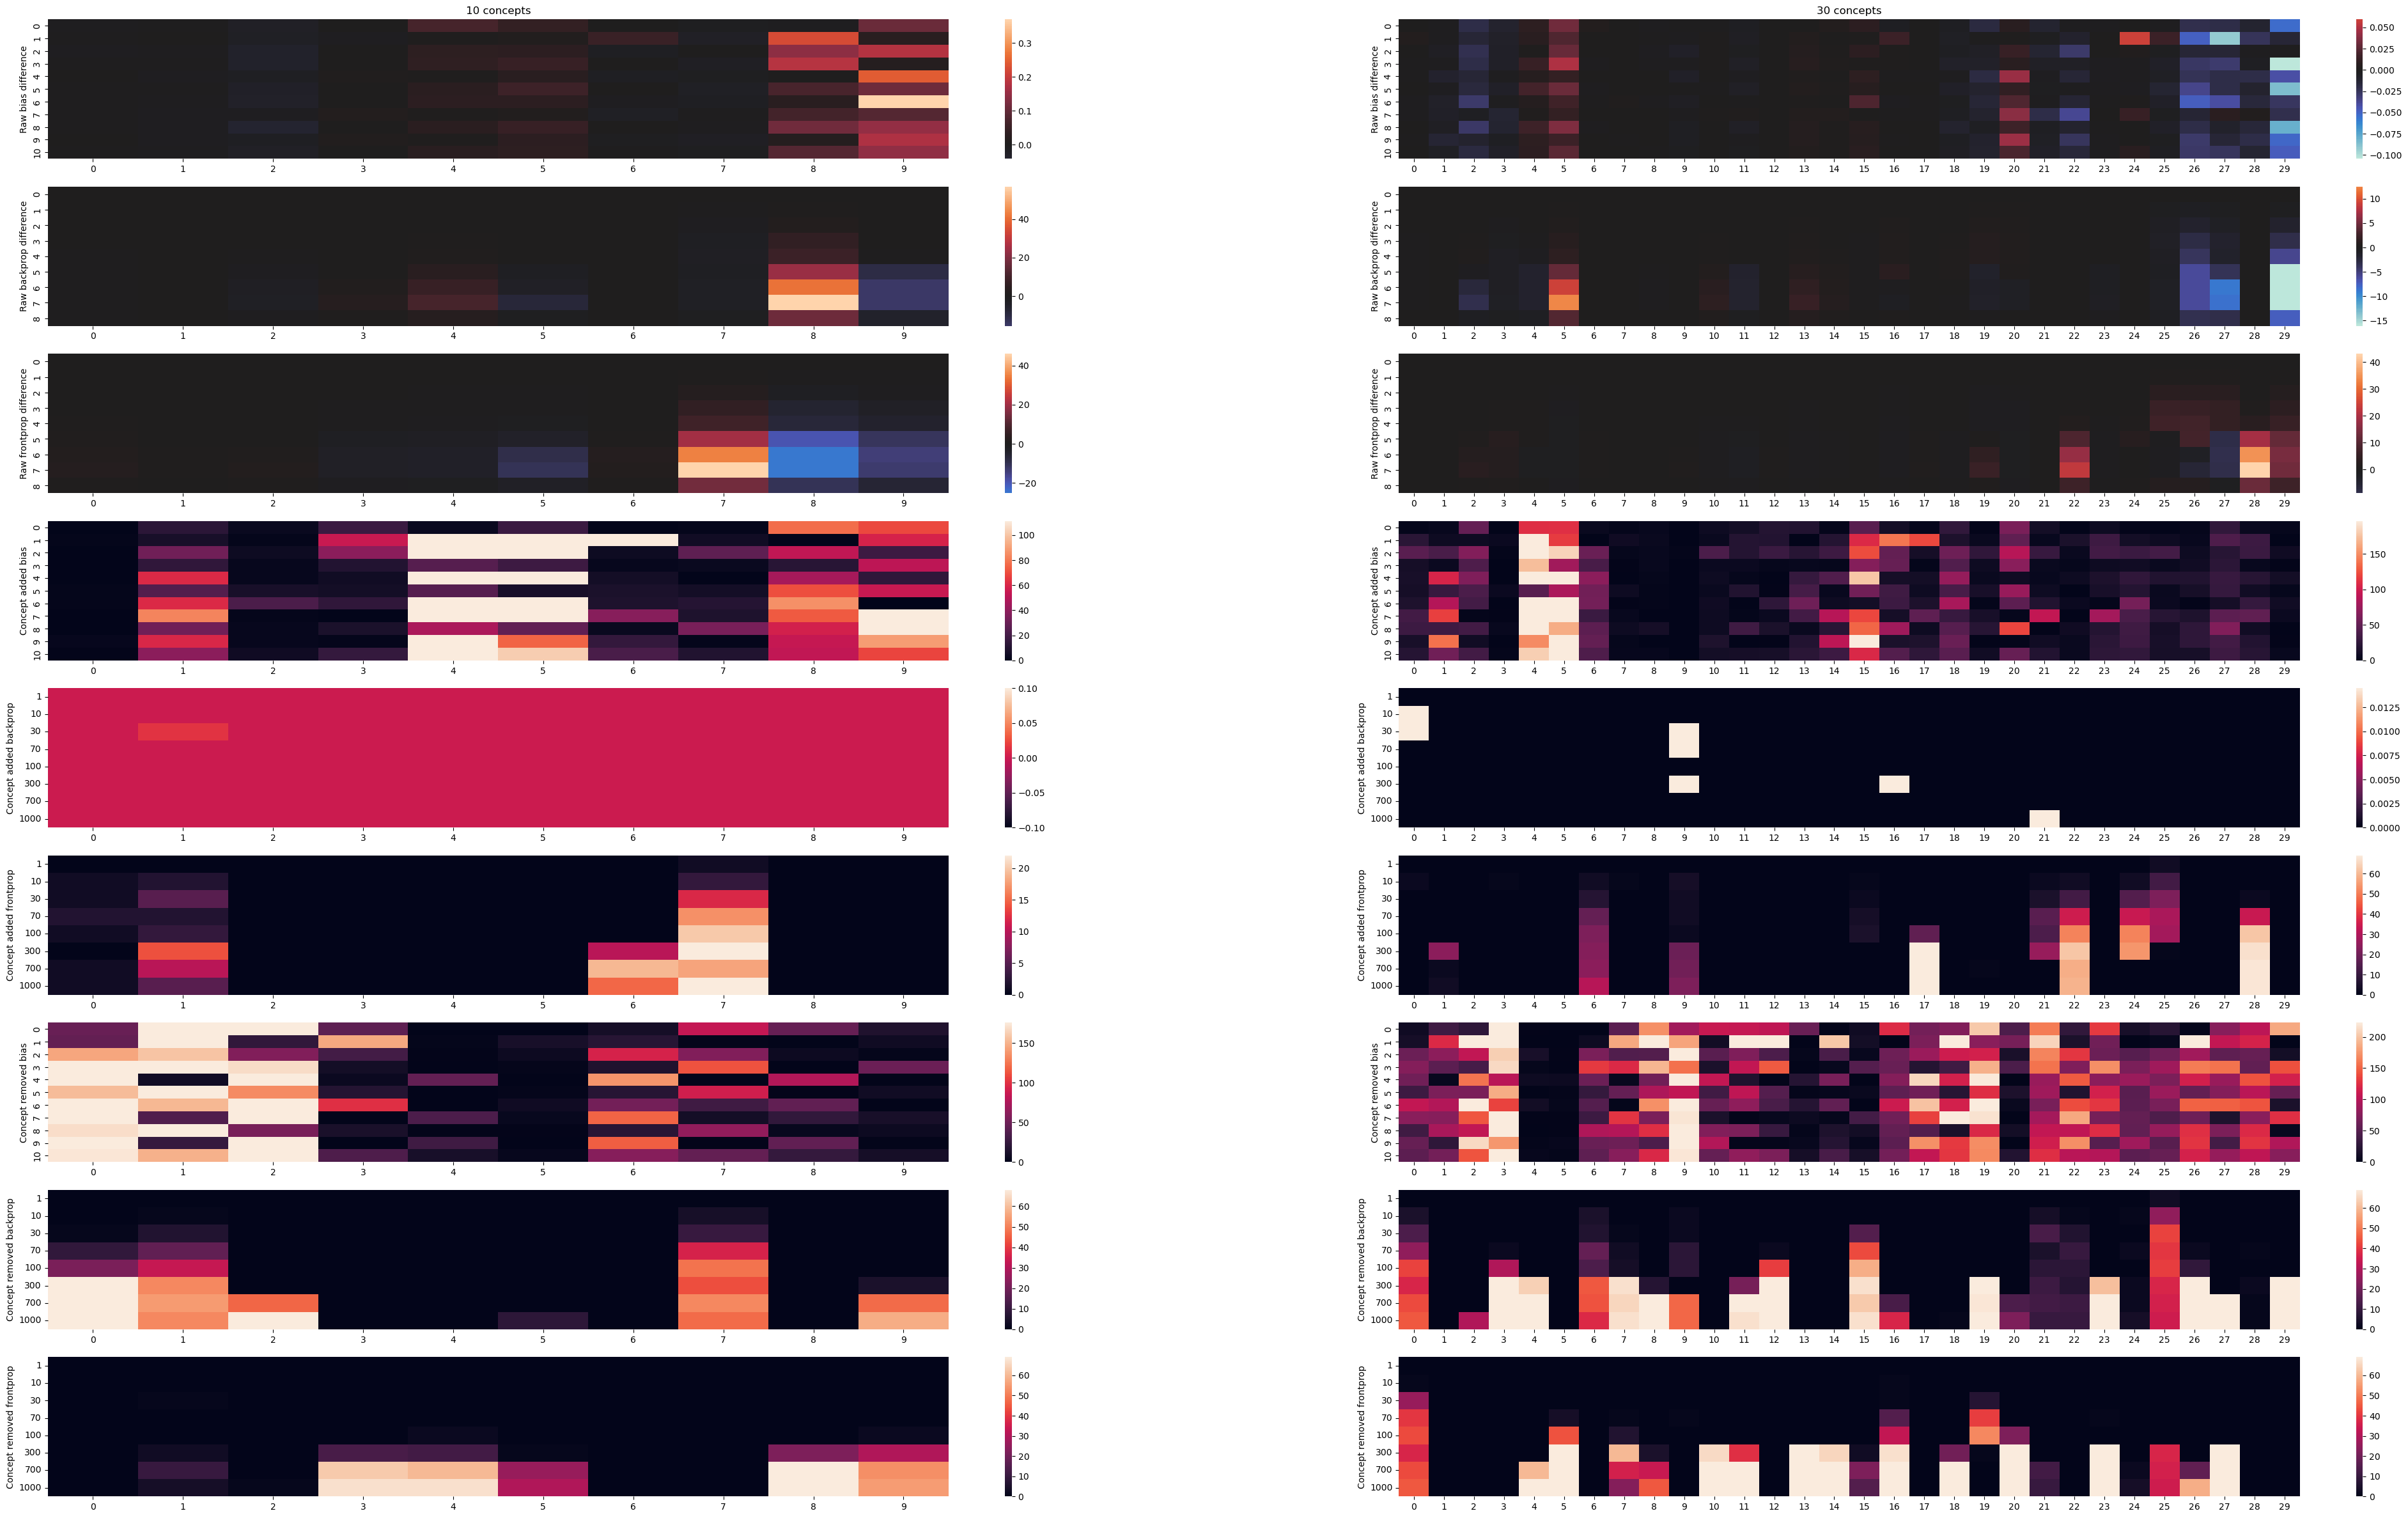

In [15]:
exp_id = 0
studied_bias = 3
concept_range = range(0,2)
concept_amounts = [10, 30, 70, 100, 300, 500, 700]
fig, axes = plt.subplots(9, len(concept_range), figsize=(50,30))
for index, concept_id in enumerate(concept_range):
    amount_of_concept = concept_amounts[concept_id]
    with open(f"/data/4vitry/models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"/data/4vitry/models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    table = []
    for i in range(10):
        table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
    table.append(sum(table)/len(table))

    table1 = []
    for i in range(10):
        table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
    table1.append(sum(table1)/len(table1))

    table2 = []
    for i in range(10):
        table2.append(((bias_res[studied_bias][i][1] == 0) & (bias_res[studied_bias][i][0] > 0)).sum(axis=0))
    table2.append(sum(table2)/len(table2))

    descent_added = []
    descent_removed = []
    ascent_added = []
    ascent_removed = []
    descent_raw_difference = []
    ascent_raw_difference = []
    for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
        table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
        descent_added.append(table_["descent_added_concept"]/table_["data_size"])
        descent_removed.append(table_["descent_removed_concept"])
        ascent_added.append(table_["ascent_added_concept"])
        ascent_removed.append(table_["ascent_removed_concept"])
        descent_raw_difference.append(table_["descent_raw_difference"])
        ascent_raw_difference.append(table_["ascent_raw_diff"])
    descent_raw_difference.append(sum(descent_raw_difference)/len(descent_raw_difference))
    ascent_raw_difference.append(sum(ascent_raw_difference)/len(ascent_raw_difference))

    sb.heatmap(table, center=0, annot=False, ax=axes[0][index])
    axes[0][index].set(ylabel="Raw bias difference", title=f"{amount_of_concept} concepts")
    sb.heatmap(descent_raw_difference, center=0, ax=axes[1][index])
    axes[1][index].set(ylabel="Raw backprop difference")
    sb.heatmap(ascent_raw_difference, center=0, ax=axes[2][index])
    axes[2][index].set(ylabel="Raw frontprop difference")
    sb.heatmap(table1, vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[3][index])
    axes[3][index].set(ylabel="Concept added bias")
    sb.heatmap(table2, vmin=0, vmax=table2[-1].max(), annot=False, ax=axes[6][index])
    axes[6][index].set(ylabel="Concept removed bias")
    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(descent_added, vmin=0, vmax=descent_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[4][index])
    axes[4][index].set(ylabel="Concept added backprop")

    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(descent_removed, vmin=0, vmax=descent_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[7][index])
    axes[7][index].set(ylabel="Concept removed backprop")
    sb.heatmap(ascent_added, vmin=0, vmax=ascent_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[5][index])
    axes[5][index].set(ylabel="Concept added frontprop")
    sb.heatmap(ascent_removed, vmin=0, vmax=ascent_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[8][index])
    axes[8][index].set(ylabel="Concept removed frontprop")

    v_bias_identified = np.array(descent_removed)
    v_bias_real = table1[-1]
    res = np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
    print(f"For {amount_of_concept} concept, the vector similarity is : {res}")

In [80]:
def normalize(a):
    b = (a - a.min())/(a.max() - a.min())
    return b/b.sum()

normalize(np.array(truc)) @ normalize(table1[-1]).T

array([6.19386430e-06, 5.43403792e-05, 1.21191960e-04, 2.01876017e-04,
       2.37653963e-04, 2.93349480e-04, 2.93510001e-04, 2.85641925e-04])

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.         0.02026047 0.02026047 0.03522427 0.07134578 0.11322706
 0.12315469 0.11519522]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.         0.         0.00229985 0.01781439 0.05393329 0.11537879
 0.13220349 0.13486151]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


...

For 10 concept, the vector similarity is : [0.         0.         0.02984095 0.07657822 0.07281117 0.09801717
 0.10612371 0.17904567]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.         0.01441814 0.05293094 0.1151583  0.14814995 0.17802346
 0.19936721 0.20678888]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.00624652 0.01314273 0.06828828 0.15215918 0.20316123 0.2881438
 0.3146795  0.3143715 ]


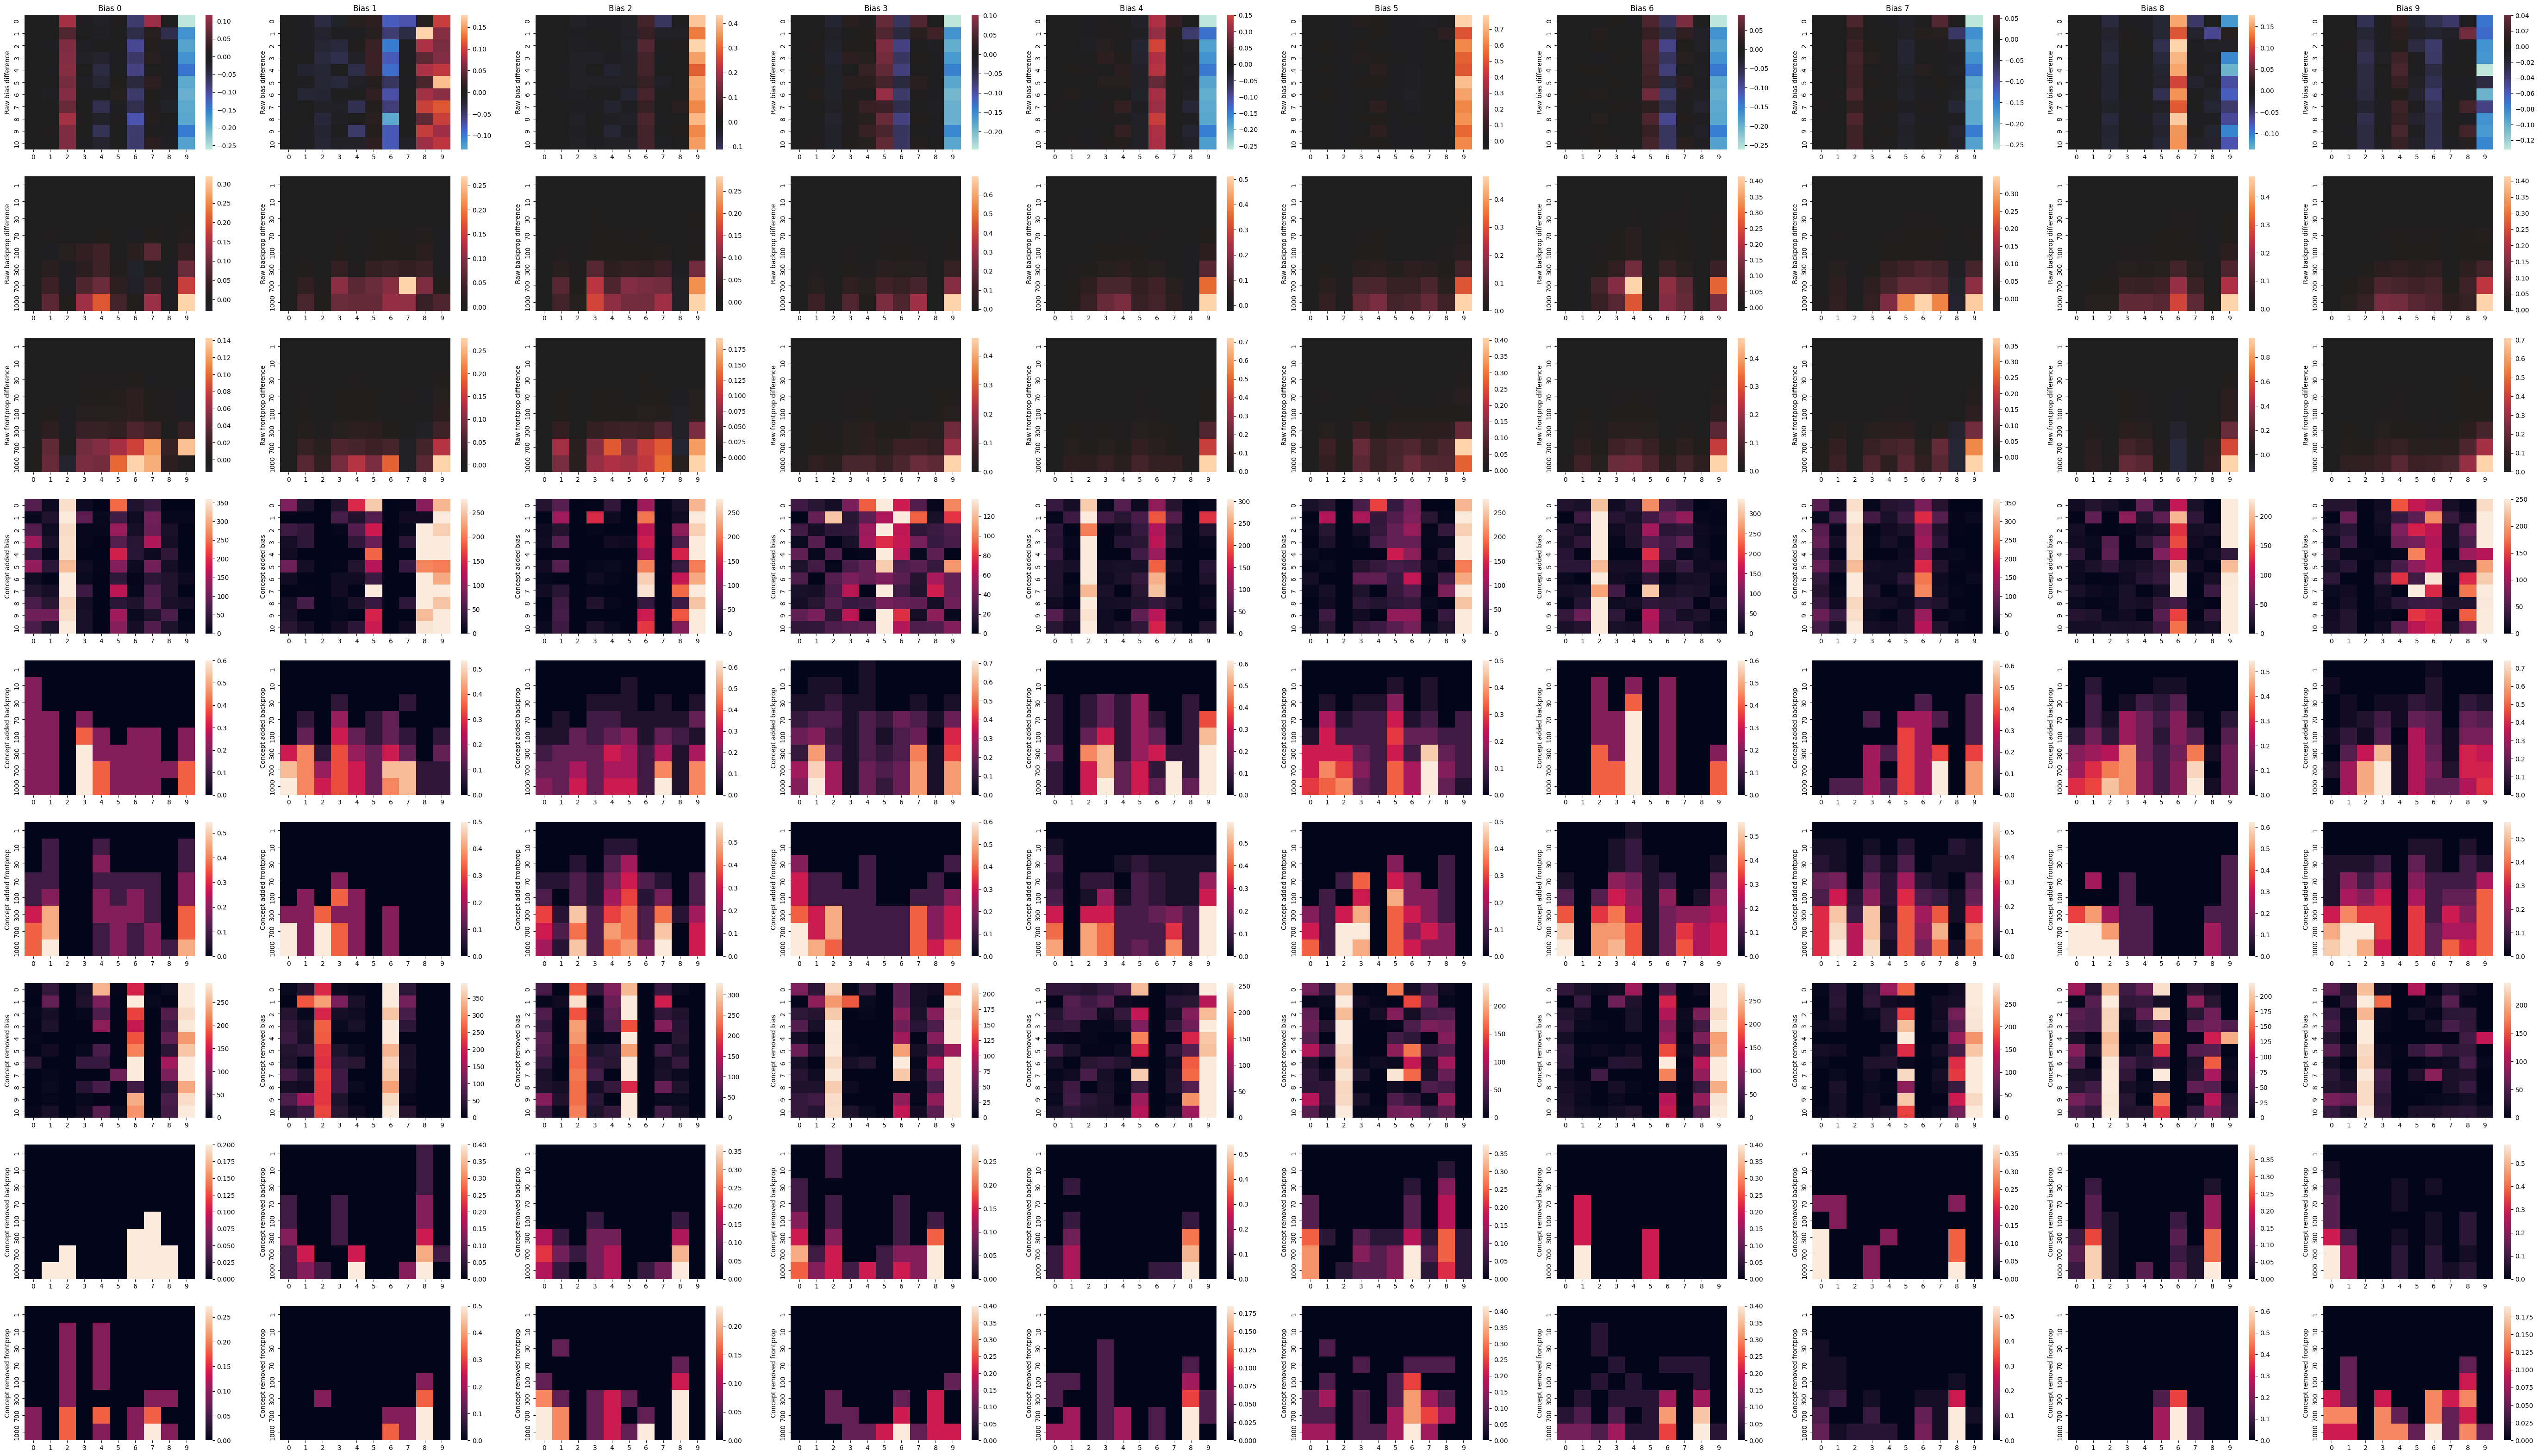

In [24]:
exp_id = 0
concept_id = 0
concept_amounts = [10, 30, 70, 100, 300, 500, 700]
amount_of_concept = concept_amounts[concept_id]
bias_range = range(10)
fig, axes = plt.subplots(9, len(bias_range), figsize=(70,40))
for index, studied_bias in enumerate(bias_range):
    with open(f"models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    table = []
    for i in range(10):
        table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
    table.append(sum(table)/len(table))

    table1 = []
    for i in range(10):
        table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
    table1.append(sum(table1)/len(table1))

    table2 = []
    for i in range(10):
        table2.append(((bias_res[studied_bias][i][1] == 0) & (bias_res[studied_bias][i][0] > 0)).sum(axis=0))
    table2.append(sum(table2)/len(table2))

    neg_added = []
    neg_removed = []
    pos_added = []
    pos_removed = []
    raw_n_diff = []
    raw_p_diff = []
    for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
        table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
        neg_added.append(table_[0]/table_[2])
        neg_removed.append(table_[1]/table_[2])
        pos_added.append(table_[3]/table_[5])
        pos_removed.append(table_[4]/table_[5])
        raw_n_diff.append(table_[6])
        raw_p_diff.append(table_[7])

    sb.heatmap(table, center=0, annot=False, ax=axes[0][index])
    axes[0][index].set(ylabel="Raw bias difference", title=f"Bias {studied_bias}")
    sb.heatmap(raw_n_diff, center=0, ax=axes[1][index], yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])
    axes[1][index].set(ylabel="Raw backprop difference")
    sb.heatmap(raw_p_diff, center=0, ax=axes[2][index], yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])
    axes[2][index].set(ylabel="Raw frontprop difference")
    sb.heatmap(table1, vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[3][index])
    axes[3][index].set(ylabel="Concept added bias")
    sb.heatmap(table2, vmin=0, vmax=table2[-1].max(), annot=False, ax=axes[6][index])
    axes[6][index].set(ylabel="Concept removed bias")
    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(neg_added, vmin=0, vmax=neg_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[4][index])
    axes[4][index].set(ylabel="Concept added backprop")

    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(neg_removed, vmin=0, vmax=neg_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[7][index])
    axes[7][index].set(ylabel="Concept removed backprop")
    sb.heatmap(pos_added, vmin=0, vmax=pos_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[5][index])
    axes[5][index].set(ylabel="Concept added frontprop")
    sb.heatmap(pos_removed, vmin=0, vmax=pos_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[8][index])
    axes[8][index].set(ylabel="Concept removed frontprop")

    v_bias_identified = np.array(neg_added)
    v_bias_real = table1[-1]
    res = np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
    print(f"For {amount_of_concept} concept, the vector similarity is : {res}")

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[Text(0.5, 23.52222222222222, 'Number of backpropagation step'),
 Text(50.722222222222214, 0.5, 'Number of concept'),
 Text(0.5, 1.0, 'Similarity between real and identified bias encoding')]

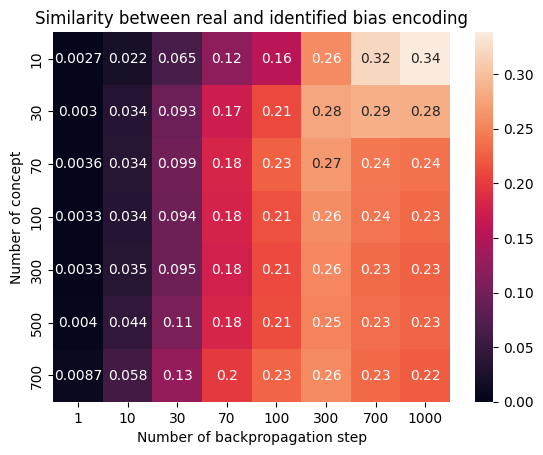

In [19]:
exp_range = range(5,10)
concept_range = range(0,7)
steps_amounts = [1, 10, 30, 70, 100, 300, 700, 1000]
concept_amounts = [10, 30, 70, 100, 300, 500, 700]

result = np.array([[0. for j in steps_amounts] for i in concept_range])
for exp_id in exp_range:
    temp_res = np.array([[0. for j in steps_amounts] for i in concept_range])
    for studied_bias in range(10):
        # fig, axes = plt.subplots(3, len(concept_range), figsize=(20,5))
        for index, concept_id in enumerate(concept_range):
            amount_of_concept = concept_amounts[concept_id]
            with open(f"models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
                bias_res = pkl.load(f)
            with open(f"models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
                concept_res = pkl.load(f)
            table = []
            for i in range(10):
                table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
            table.append(sum(table)/len(table))
            # sb.heatmap(table[-1:], center=0, annot=False, ax=axes[0][index])

            table1 = []
            for i in range(10):
                table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
            table1.append(sum(table1)/len(table1))
            # sb.heatmap(table1[-1:], vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[1][index])

            truc = []
            for step_amount in steps_amounts:
                table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
                truc.append(table_[0])
            v_bias_identified = np.array(truc)
            v_bias_real = table1[-1]
            temp_res[index] += np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
            # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
            # sb.heatmap(truc, vmin=0, vmax=truc[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[2][index])
    result += (temp_res/10)
ax = sb.heatmap(result/len(exp_range), vmin=0, xticklabels=steps_amounts, yticklabels=concept_amounts, annot=True)
ax.set(xlabel="Number of backpropagation step", ylabel="Number of concept", title="Similarity between real and identified bias encoding")

In [111]:
from scipy.stats import kendalltau
a = np.array([3,2,1, 4, 9, 8, 6, 7, 5])
b = np.array([3,1,2,9, 8, 7, 5, 6, 4])
kendalltau(a, b)

SignificanceResult(statistic=np.float64(0.6666666666666666), pvalue=np.float64(0.012665343915343916))

In [112]:
kendalltau(np.argsort(a), np.argsort(b))

SignificanceResult(statistic=np.float64(0.5555555555555556), pvalue=np.float64(0.04461529982363316))

In [103]:
v_bias_identified[0].shape

(700,)

[Text(0.5, 23.52222222222222, 'Number of backpropagation step'),
 Text(50.722222222222214, 0.5, 'Number of concept'),
 Text(0.5, 1.0, 'Similarity between real and identified bias encoding')]

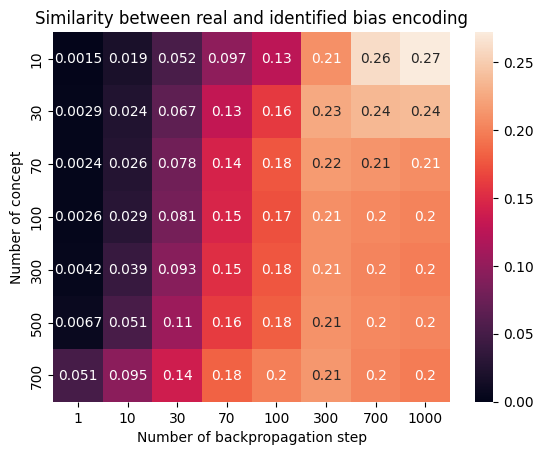

In [98]:
ax = sb.heatmap(result/len(exp_range), vmin=0, xticklabels=steps_amounts, yticklabels=concept_amounts, annot=True)
ax.set(xlabel="Number of backpropagation step", ylabel="Number of concept", title="Similarity between real and identified bias encoding")

<Axes: >

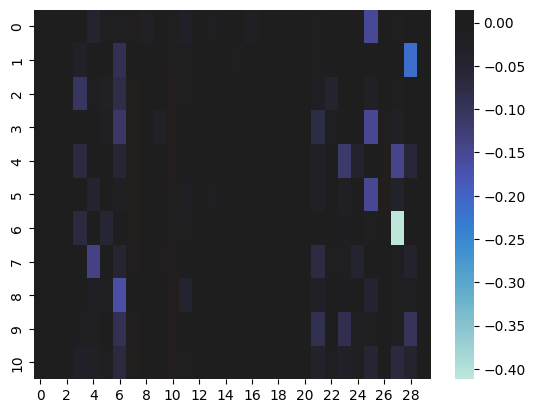

In [40]:
with open(f"models/{exp_name}/bias_{exp_id}_{1}.pkl", "rb") as f:
    bias_res = pkl.load(f)

table = []
for i in range(10):
    table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
table.append(sum(table)/len(table))
sb.heatmap(table, center=0, annot=False)

<Axes: >

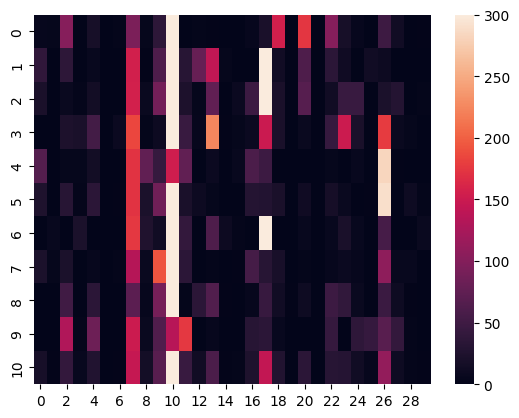

In [41]:
table1 = []
for i in range(10):
    table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
table1.append(sum(table1)/len(table1))
sb.heatmap(table1, vmin=0, vmax=300, annot=False)   

<Axes: >

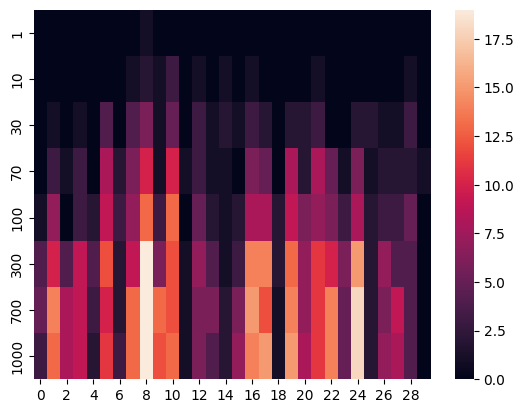

In [43]:
truc = []
for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
    table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
    truc.append(table_[0])
# table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap(truc, vmin=0, vmax=truc[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])

<Axes: >

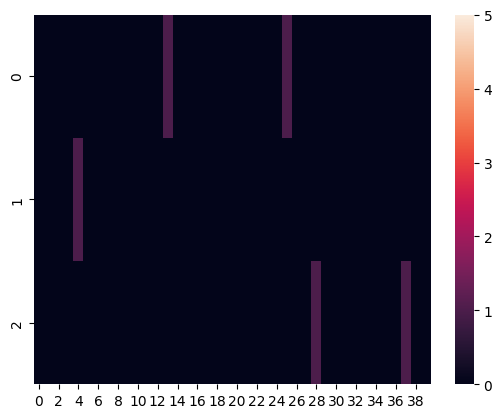

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

<Axes: >

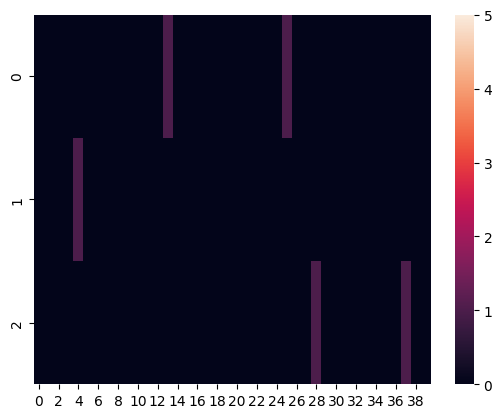

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

In [30]:
table_

(array([0., 0., 2., 0., 2., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        1., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,

In [17]:
data_path = os.getcwd() + "/data/MNIST"
device = "cuda"
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=res["batch_size"], data_label_correlation=res["test_correlation"], train=False)
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix

assert(os.path.exists(f"models/{exp_name}/model_{exp_id}"))
model.load_state_dict(torch.load(f"models/{exp_name}/model_{exp_id}", weights_only=True))

base_acc = test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 78.1%, Avg loss: 0.659705 



In [19]:
import seaborn as sb

<Axes: >

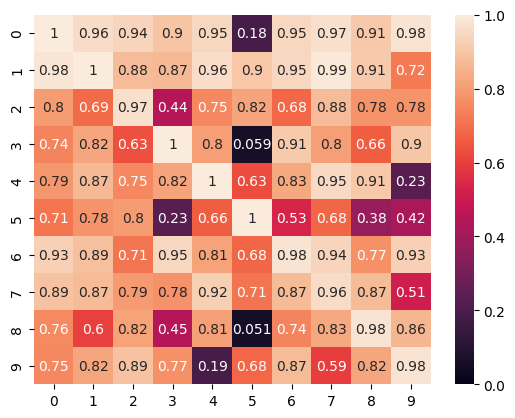

In [21]:
sb.heatmap(base_acc, vmin=0, vmax=1, annot=True)

<Axes: >

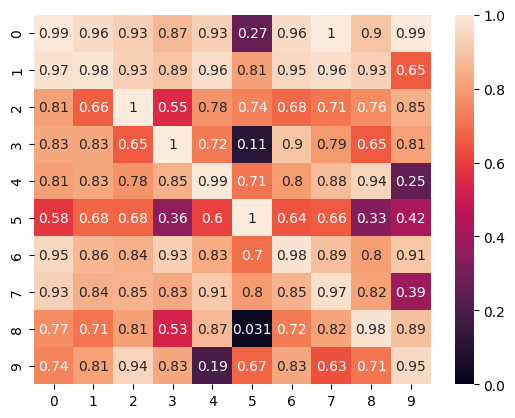

In [20]:
sb.heatmap(res["accuracy_matrix"], vmin=0, vmax=1, annot=True)